# GRA: lion

project = ```GRA```, host = ```mach```, device = ```cuda:3```

## Goals:

Test these Lion extensions:

**relativistic**

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Main

In [3]:
from optimzers import *
from test.test import *

### w/o amp

In [4]:
cfg = TrainConfig(dataset='CIFAR10', epochs=100, device=device, verbose=True, amp=False)

In [5]:
kws = dict(betas=(0.8, 0.99), use_curvature=False)

experiments_rel_lion = [
    Experiment(
        f"Relativistic Lion — lr={lr},mass={m}",
        make_opt(RelativisticLion, lr=lr, mass=m, **kws),
    ) for lr, m in itertools.product([1e-3], [50, 100, 200])
]
experiments_lion = [
    Experiment(
        f"Lion — lr={lr},b1={b1}",
        make_opt(Lion, lr=lr, betas=(b1, 0.99)),
    ) for lr, b1 in itertools.product([1e-5, 1e-4, 1e-3, 1e-2], [0.8, 0.9])
]

experiments = experiments_rel_lion + experiments_lion

print(experiments)

[
    Experiment(
        name='Relativistic Lion — lr=0.001,mass=50',
        opt_fn=<function make_opt.<locals>._fn at 0x75348e414c20>
    ),
    Experiment(
        name='Relativistic Lion — lr=0.001,mass=100',
        opt_fn=<function make_opt.<locals>._fn at 0x75348e414ea0>
    ),
    Experiment(
        name='Relativistic Lion — lr=0.001,mass=200',
        opt_fn=<function make_opt.<locals>._fn at 0x75348e414d60>
    ),
    Experiment(name='Lion — lr=1e-05,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x75348e414f40>),
    Experiment(name='Lion — lr=1e-05,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x75348e414fe0>),
    Experiment(name='Lion — lr=0.0001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x75348e415080>),
    Experiment(name='Lion — lr=0.0001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x75348e415120>),
    Experiment(name='Lion — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x75348e4151c0>),
    Experiment(name='Lion — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x75348e415260>),
    Experiment(name='Lion — lr=0.01,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x75348e415300>),
    Experiment(name='Lion — lr=0.01,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x75348e4153a0>)
]

In [6]:
results = run_experiments(experiments, cfg=cfg, seeds=[0])

--- Training (CIFAR10) ---

Model: ConvNet | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 50
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/100:  Train Loss 1.0840  |  Test Acc 73.51%

Epoch    5/100:  Train Loss 0.2688  |  Test Acc 86.27%

Epoch   10/100:  Train Loss 0.1102  |  Test Acc 87.18%

...

Epoch   85/100:  Train Loss 2.3038  |  Test Acc 10.00%

Epoch   90/100:  Train Loss 2.3038  |  Test Acc 10.00%

Epoch   95/100:  Train Loss 2.3038  |  Test Acc 10.00%

Epoch  100/100:  Train Loss 2.3038  |  Test Acc 10.00%

Finished in 513.2s

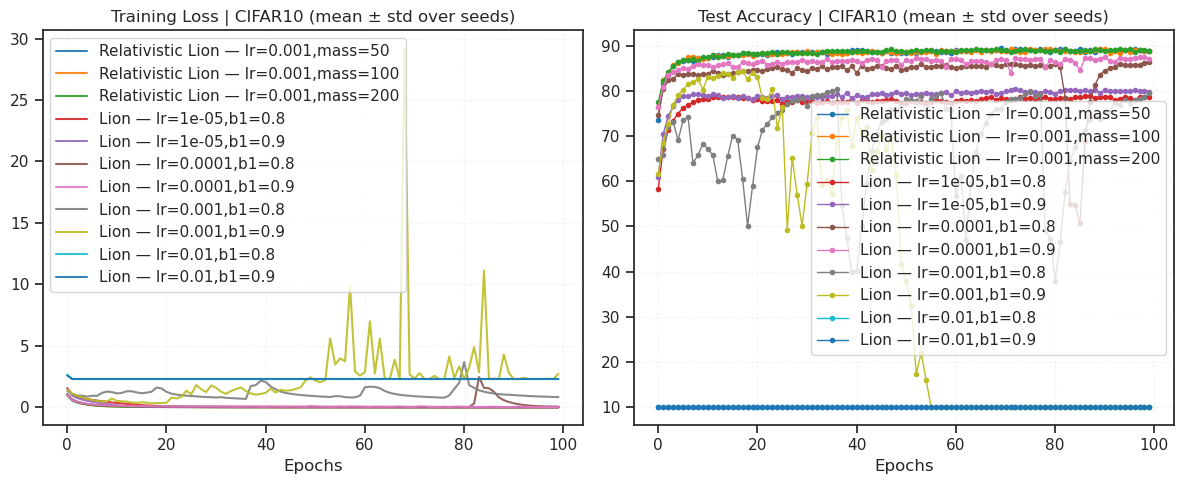

In [7]:
plot_results(results, title="CIFAR10 (mean ± std over seeds)")

In [8]:
avg_scores = {k: np.round(d['test_acc'][-5:].mean(), decimals=1) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Lion — lr=0.01,b1=0.8': 10.0,
 'Lion — lr=0.01,b1=0.9': 10.0,
 'Lion — lr=0.001,b1=0.9': 41.9,
 'Lion — lr=0.001,b1=0.8': 70.0,
 'Lion — lr=1e-05,b1=0.8': 77.6,
 'Lion — lr=1e-05,b1=0.9': 79.0,
 'Lion — lr=0.0001,b1=0.8': 83.5,
 'Lion — lr=0.0001,b1=0.9': 86.2,
 'Relativistic Lion — lr=0.001,mass=50': 88.2,
 'Relativistic Lion — lr=0.001,mass=100': 88.2,
 'Relativistic Lion — lr=0.001,mass=200': 88.3}